# "Preprocessing" Kayson's Generated networks 

(i.e.: reshaping it to (num_subjects, n_nodes, n_nodes), and thresholding it to 10 percent.)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.preprocessing.threshold_to_density import threshold_to_density

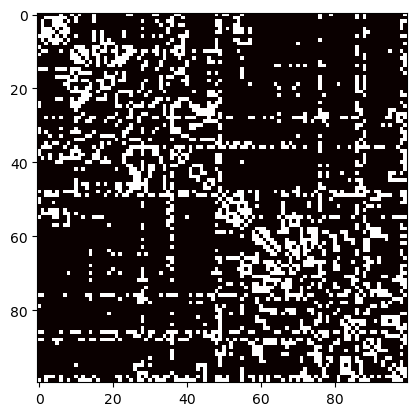

In [25]:
# Get distance matrices 
# generation_type = "diffusion" 
# generation_type = "routing" # choose either "diffusion", "propagation", or "routing"
generation_type = "propagation"
density = 10 # in percent

conns = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/kaysons_generated_networks/optimalnetworks/{generation_type}_lastmats.npy").T
plt.imshow(conns[0,:,:], cmap='hot', interpolation='nearest')

# Get inverse distance matrix
distance_matrix = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_{generation_type}/02_distance_matrices/distance_matrix_100.npy")
inverse_distance_matrix = 1/(distance_matrix + 1e-8)

# Get output path 
output_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_{generation_type}/01_connectomes")
output_path.mkdir(parents=True, exist_ok=True)


Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)

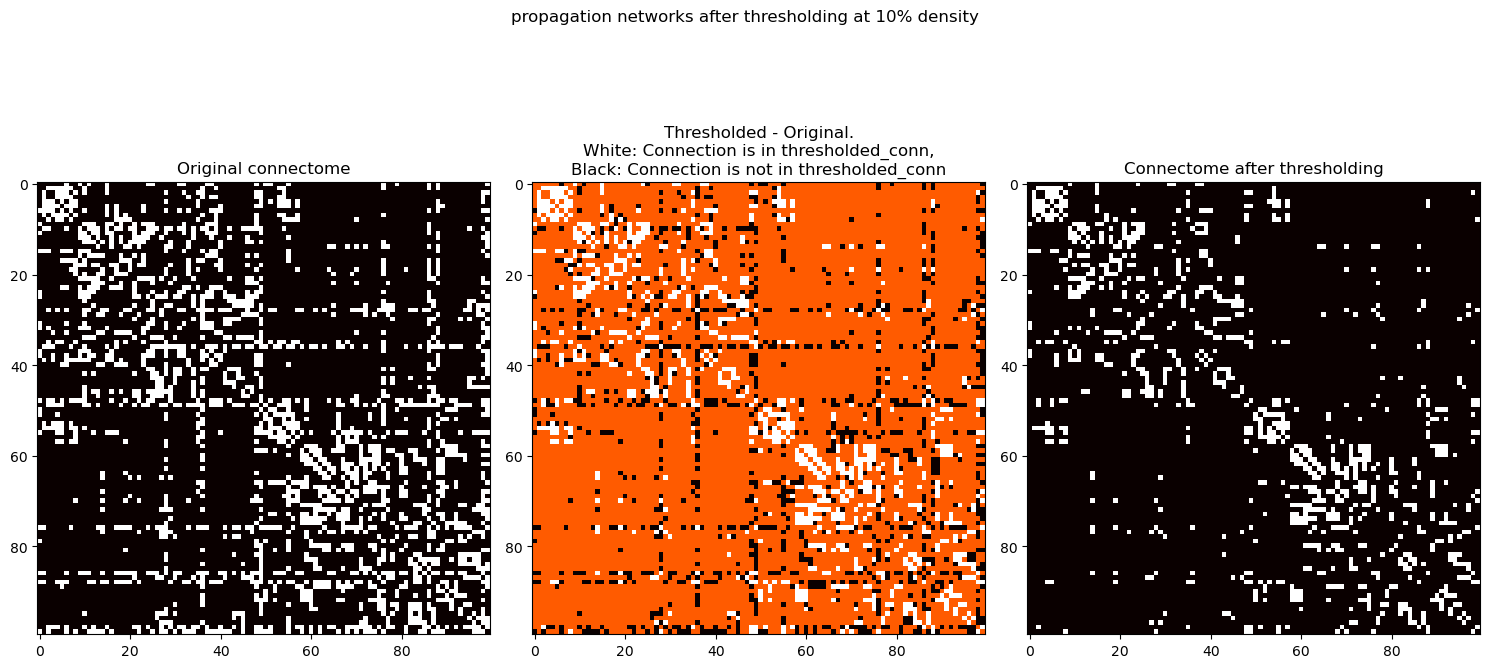

In [26]:
# Threshold connectomes and save them

thres_conn_arr = []

for c in conns: 
    one_weighted_conn = inverse_distance_matrix * conns[0,:,:]
    thres_conn, final_density = threshold_to_density(one_weighted_conn, density, conn_type="connectomes")
    thres_conn_arr.append(thres_conn)
    
thres_conn_arr = np.array(thres_conn_arr)

np.save(output_path / f"{generation_type}_{density}_percent.npy", thres_conn_arr)

plt.figure(figsize=(15,8))


plt.subplot(1,3,1)
plt.imshow(conns[0,:,:], cmap='hot', interpolation='nearest')
plt.title("Original connectome")

plt.subplot(1,3,2)
plt.imshow(thres_conn_arr[0,:,:]*2-conns[0,:,:], cmap='hot', interpolation='nearest')
plt.title("Thresholded - Original.\nWhite: Connection is in thresholded_conn,\nBlack: Connection is not in thresholded_conn")

plt.subplot(1,3,3)
plt.imshow(thres_conn_arr[0,:,:], cmap='hot', interpolation='nearest')
plt.title("Connectome after thresholding")

plt.suptitle(f"{generation_type} networks after thresholding at 10% density")
plt.tight_layout()

# Testing stuff

In [27]:
# generation_type = "propagation" 
# conns_prop = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/kaysons_generated_networks/{generation_type}_{density}_percent.npy").T
# generation_type = "diffusion"
# conns_diff = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/kaysons_generated_networks/{generation_type}_{density}_percent.npy").T

# id = 4

# plt.subplot(1,2,1)
# plt.title("Diffusion")
# plt.imshow(conns_diff[id,:,:], cmap='hot', interpolation='nearest')
# plt.subplot(1,2,2)
# plt.title("Propagation")
# plt.imshow(conns_prop[id,:,:]-conns_prop[id,:,:], cmap='hot', interpolation='nearest')
# plt.show()

In [28]:
conn_diff = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion.npy") 
conn_prop = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation.npy")

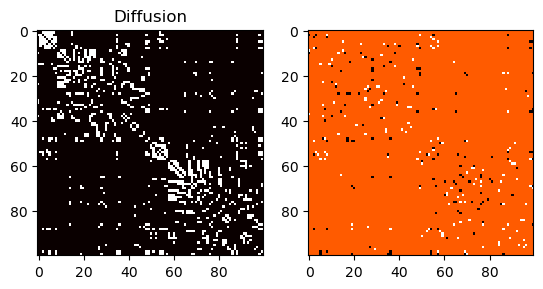

In [29]:
id = 4

plt.subplot(1,2,1)
plt.title("Diffusion")
plt.imshow(conn_diff[id,:,:], cmap='hot', interpolation='nearest')
plt.subplot(1,2,2)
# plt.title("Propagation")
plt.imshow(conn_prop[id,:,:]-conn_diff[3,:,:], cmap='hot', interpolation='nearest')
plt.show()